In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from tensorflow import keras

In [2]:
df = pd.read_csv("./google_stock_prices.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1258 non-null   object 
 1   Open    1258 non-null   float64
 2   High    1258 non-null   float64
 3   Low     1258 non-null   float64
 4   Close   1258 non-null   object 
 5   Volume  1258 non-null   object 
dtypes: float64(3), object(3)
memory usage: 59.1+ KB


In [4]:
data_set = df.iloc[:, 1:2].values
training_length = int(len(data_set) * 0.8)

scaler = MinMaxScaler()
data_set = scaler.fit_transform(data_set)

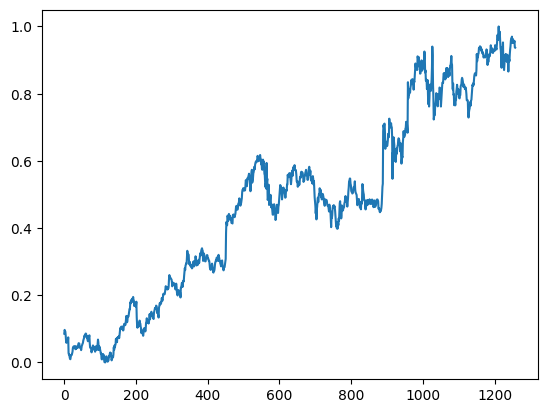

In [5]:
plt.plot(data_set)

In [6]:
X_train = []
y_train = []

for i in range(60, training_length):
    X_train.append(data_set[i-60:i])
    y_train.append(data_set[i])

X_train = np.array(X_train)
y_train = np.array(y_train)

In [7]:
X_test = []
y_test = []

for i in range(len(data_set) - training_length - 60, len(data_set)):
    X_test.append(data_set[i-60:i])
    y_test.append(data_set[i])

X_test = np.array(X_test)
y_test = np.array(y_test)

In [8]:
model = keras.models.Sequential()

model.add(keras.layers.SimpleRNN(50, return_sequences=True, activation="tanh",input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(keras.layers.Dropout(0.2))

model.add(keras.layers.SimpleRNN(50, return_sequences=True, activation="tanh"))
model.add(keras.layers.Dropout(0.2))

model.add(keras.layers.SimpleRNN(50, return_sequences=True, activation="tanh"))
model.add(keras.layers.Dropout(0.2))

model.add(keras.layers.SimpleRNN(50, activation="tanh"))
model.add(keras.layers.Dropout(0.2))

model.add(keras.layers.Dense(1, activation="linear"))

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (None, 60, 50)            2600      
                                                                 
 dropout (Dropout)           (None, 60, 50)            0         
                                                                 
 simple_rnn_1 (SimpleRNN)    (None, 60, 50)            5050      
                                                                 
 dropout_1 (Dropout)         (None, 60, 50)            0         
                                                                 
 simple_rnn_2 (SimpleRNN)    (None, 60, 50)            5050      
                                                                 
 dropout_2 (Dropout)         (None, 60, 50)            0         
                                                                 
 simple_rnn_3 (SimpleRNN)    (None, 50)                

In [9]:
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [10]:
history = model.fit(X_train, y_train, epochs = 100, batch_size=16, validation_split=0.1)

Epoch 1/100


54/54 [==============================] - 12s 116ms/step - loss: 0.4750 - mae: 0.5482 - val_loss: 0.0885 - val_mae: 0.2819
Epoch 2/100
54/54 [==============================] - 6s 103ms/step - loss: 0.2839 - mae: 0.4254 - val_loss: 0.0053 - val_mae: 0.0641
Epoch 3/100
54/54 [==============================] - 5s 101ms/step - loss: 0.2061 - mae: 0.3643 - val_loss: 0.0139 - val_mae: 0.0950
Epoch 4/100
54/54 [==============================] - 4s 76ms/step - loss: 0.1667 - mae: 0.3238 - val_loss: 0.0272 - val_mae: 0.1444
Epoch 5/100
54/54 [==============================] - 5s 87ms/step - loss: 0.1303 - mae: 0.2848 - val_loss: 0.0122 - val_mae: 0.0939
Epoch 6/100
54/54 [==============================] - 5s 91ms/step - loss: 0.1037 - mae: 0.2521 - val_loss: 0.0115 - val_mae: 0.0879
Epoch 7/100
54/54 [==============================] - 6s 104ms/step - loss: 0.0712 - mae: 0.2071 - val_loss: 0.0207 - val_mae: 0.1224
Epoch 8/100
54/54 [==============================] - 5s 84ms/step - l

In [11]:
loss, mae = model.evaluate(X_test, y_test)

print(f"{loss=}")
print(f"{mae=}")

34/34 [==============================] - 1s 25ms/step - loss: 0.0028 - mae: 0.0357
loss=0.0027708616107702255
mae=0.03566797450184822


In [12]:
new_data = X_test[:1]
model.predict(new_data)

1/1 [==============================] - 1s 1s/step


array([[0.182113]], dtype=float32)

In [13]:
y_pred = scaler.inverse_transform(model.predict(X_test))
y_test = scaler.inverse_transform(y_test)

34/34 [==============================] - 1s 28ms/step


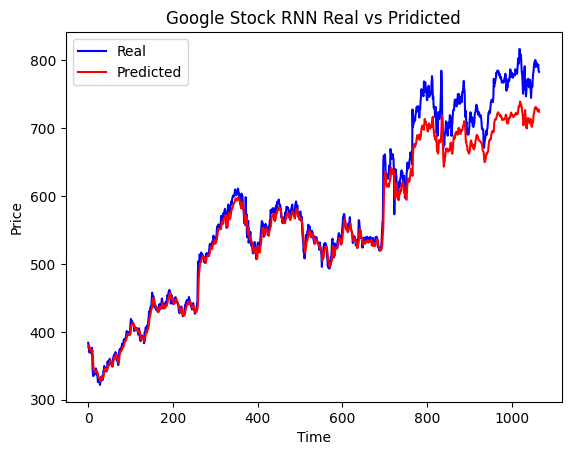

In [22]:
plt.title("Google Stock RNN Real vs Pridicted")
plt.plot(y_test, color="blue", label="Real")
plt.plot(y_pred, color="red", label="Predicted")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()